<a href="https://colab.research.google.com/github/PavankumarNandyala/AI-Engineer-Projects/blob/main/Session_01_AI_Engineering_Landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 01 - AI Engineering Landscape

This notebook supports the practical activity for Session 01: mapping a real business process into **data**, **model**, **interface**, **evaluation**, and **deployment** components.

You do not need to train a model today. The goal is to think like an AI engineer before writing production code.


## Learning goals

By the end of this notebook you should be able to:

1. Load and inspect example workplace AI opportunities.
2. Distinguish predictive ML candidates from GenAI candidates.
3. Create a reusable AI use-case canvas.
4. Produce a small, GitHub-ready artefact for discussion.


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("/content/DataSet/business_process_ai_mapping_examples.csv")
canvas_path = Path("/content/DataSet/blank_ai_use_case_canvas.csv")

examples = pd.read_csv(DATA_PATH)
examples.head(3)

,process_id,organisation_context,business_process,data_inputs,predictive_ml_candidate,genai_candidate,interface,evaluation_metric,deployment_route,governance_risks
0,P001,NHS trust operations team,Prioritising appointment backlog follow-ups,appointment history; waiting times; clinical p...,Predict missed appointment risk or likely over...,Draft patient-friendly follow-up messages usin...,Operations dashboard and message drafting note...,Precision/recall for high-risk backlog items; ...,Notebook prototype -> dashboard -> monitored w...,Special-category health data; explainability; ...
1,P002,Retail customer service,Triage inbound customer complaints,ticket text; order status; product category; c...,Classify priority or likely refund escalation,Summarise complaint and propose response options,Helpdesk side-panel,Macro-F1 for priority class; factuality and to...,Batch analysis -> agent-assist UI -> A/B monit...,Personal data; unfair treatment; hallucinated ...
2,P003,Local council housing team,Screen housing maintenance requests,request text; property type; repair category; ...,Predict urgency or expected resolution time,"Extract structured issue, location, and tenant...",Case-management form helper,MAE for days-to-resolve; extraction exact-matc...,Notebook -> API -> case-management integration,Vulnerable residents; model bias across neighb...


## 1. Inspect the AI engineering components

Each row is a workplace process. The columns map the process to the layers an AI engineer must consider:

- **Data inputs** - what evidence the system can use.
- **Model candidate** - what inference or generation could be automated or supported.
- **Interface** - where the output reaches a human.
- **Evaluation metric** - how we know it works.
- **Deployment route** - how it would move from notebook to workplace use.
- **Governance risks** - what could go wrong.


In [5]:
examples.columns.tolist()

['process_id',
 'organisation_context',
 'business_process',
 'data_inputs',
 'predictive_ml_candidate',
 'genai_candidate',
 'interface',
 'evaluation_metric',
 'deployment_route',
 'governance_risks']

In [6]:
# Show the practical mapping for one example
row = examples.loc[examples["process_id"] == "P002"].iloc[0]
for col in examples.columns:
    print(f"{col}: {row[col]}")

process_id: P002
organisation_context: Retail customer service
business_process: Triage inbound customer complaints
data_inputs: ticket text; order status; product category; customer history
predictive_ml_candidate: Classify priority or likely refund escalation
genai_candidate: Summarise complaint and propose response options
interface: Helpdesk side-panel
evaluation_metric: Macro-F1 for priority class; factuality and tone rubric for summaries
deployment_route: Batch analysis -> agent-assist UI -> A/B monitored rollout
governance_risks: Personal data; unfair treatment; hallucinated policy; tone and accessibility


## 2. Predictive ML or GenAI?

A useful first split:

- **Predictive ML** is best when you need a score, label, forecast, or ranking from historical patterns.
- **GenAI** is best when you need drafting, summarisation, extraction, transformation, or conversational assistance.
- **Both** may be useful, but they need separate evaluation methods.


In [7]:
def classify_ai_shape(row):
    predictive = isinstance(row["predictive_ml_candidate"], str) and len(row["predictive_ml_candidate"]) > 0
    genai = isinstance(row["genai_candidate"], str) and len(row["genai_candidate"]) > 0
    if predictive and genai:
        return "Both predictive ML and GenAI"
    if predictive:
        return "Predictive ML"
    if genai:
        return "GenAI"
    return "No AI candidate yet"

examples["ai_shape"] = examples.apply(classify_ai_shape, axis=1)
examples[["process_id", "business_process", "ai_shape"]]


,process_id,business_process,ai_shape
0,P001,Prioritising appointment backlog follow-ups,Both predictive ML and GenAI
1,P002,Triage inbound customer complaints,Both predictive ML and GenAI
2,P003,Screen housing maintenance requests,Both predictive ML and GenAI
3,P004,Forecast monthly departmental spend,Both predictive ML and GenAI
4,P005,Match employees to training opportunities,Both predictive ML and GenAI
5,P006,Review supplier contracts for standard clauses,Both predictive ML and GenAI
6,P007,Prioritise quality inspection alerts,Both predictive ML and GenAI
7,P008,Prioritise renewal outreach,Both predictive ML and GenAI


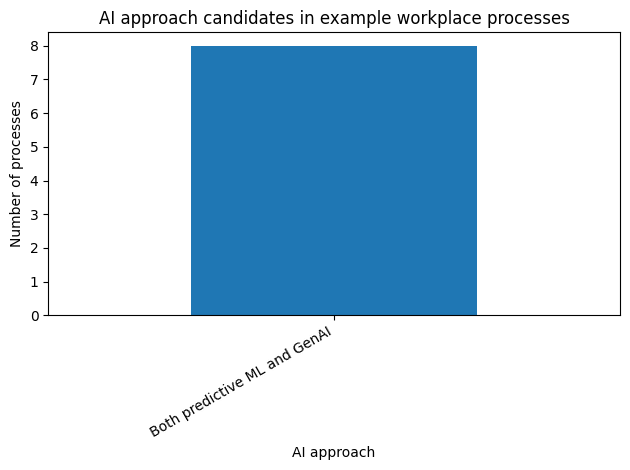

In [8]:
# Simple chart for discussion
counts = examples["ai_shape"].value_counts()
ax = counts.plot(kind="bar", title="AI approach candidates in example workplace processes")
ax.set_xlabel("AI approach")
ax.set_ylabel("Number of processes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Mini-task: select one process and produce a component map

Choose one row from the dataset or replace it with a process from your own workplace. Then complete the five core engineering components.


In [9]:
selected = examples.sample(1, random_state=7).iloc[0]

component_map = {
    "business_process": selected["business_process"],
    "data": selected["data_inputs"],
    "model": {
        "predictive_ml": selected["predictive_ml_candidate"],
        "genai": selected["genai_candidate"],
    },
    "interface": selected["interface"],
    "evaluation": selected["evaluation_metric"],
    "deployment": selected["deployment_route"],
    "governance": selected["governance_risks"],
}

component_map

{'business_process': 'Screen housing maintenance requests',
 'data': 'request text; property type; repair category; appointment slots; photo metadata',
 'model': {'predictive_ml': 'Predict urgency or expected resolution time',
  'genai': 'Extract structured issue, location, and tenant constraints'},
 'interface': 'Case-management form helper',
 'evaluation': 'MAE for days-to-resolve; extraction exact-match rate',
 'deployment': 'Notebook -> API -> case-management integration',
 'governance': 'Vulnerable residents; model bias across neighbourhoods; escalation safety'}

## 4. Exercise: create your own AI use-case canvas

Edit the values below. Use a process you understand well enough to judge whether AI would genuinely help.


In [10]:
my_canvas = {
    "Business process": "Replace with your workplace process",
    "Data inputs": "List existing data sources and owners",
    "Model approach": "Predictive ML, GenAI, both, or neither",
    "Interface": "Dashboard, API, form helper, chatbot, notebook, etc.",
    "Evaluation": "Metric, review rubric, business KPI, or risk threshold",
    "Deployment": "Notebook prototype, batch job, API, internal app, etc.",
    "Governance": "Privacy, bias, safety, accountability, human review",
}

pd.DataFrame(my_canvas.items(), columns=["Field", "Your notes"])

,Field,Your notes
0,Business process,Replace with your workplace process
1,Data inputs,List existing data sources and owners
2,Model approach,"Predictive ML, GenAI, both, or neither"
3,Interface,"Dashboard, API, form helper, chatbot, notebook..."
4,Evaluation,"Metric, review rubric, business KPI, or risk t..."
5,Deployment,"Notebook prototype, batch job, API, internal a..."
6,Governance,"Privacy, bias, safety, accountability, human r..."


## 5. Save a GitHub-ready output

The exported Markdown file can be committed to GitHub with the notebook and dataset.


In [11]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

md = "# AI Use Case Canvas\n\n"
for field, value in my_canvas.items():
    md += f"## {field}\n{value}\n\n"

output_file = output_dir / "my_ai_use_case_canvas.md"
output_file.write_text(md, encoding="utf-8")
print(f"Saved: {output_file}")

Saved: outputs/my_ai_use_case_canvas.md


## Homework reminder

Create a one-page AI use-case canvas for your workplace. Include:

- The process and current pain point:-
   Finance reviewers spend a large share of their time manually reading receipts and cross-checking policy limits; approvals are slow and inconsistent between reviewers.
- Data you would need and any data risks:-
  Receipts, claim metadata, and historical approvals contain personal financial data, so access must be restricted and retention limited; there is also a risk the historical data bakes in past reviewer bias.
- Whether the best first approach is predictive ML or GenAI:-
  GenAI first (receipt extraction) is the lower-risk starting point, since it only removes manual data entry. The predictive risk-scoring model is a second phase once there is a clean, labelled dataset of past decisions.
- How colleagues would use the output:-
  Reviewers see pre-filled, extracted claim data plus a plain-English flag explanation directly in the expenses tool, not a separate system to log into.
- How you would evaluate success:-
  Extraction exact-match rate, reviewer time per claim, and a quarterly audit comparing model flags to actual policy exceptions found later.
- One governance risk and one mitigation:-
  Risk - the model could disproportionately flag certain teams or expense categories. Mitigation - monthly fairness review of flag rates by team, with a human always making the final call.
